# EP2  Machine Learning: Spotify Tracks

## 2. Modelizacion supervisada y no supervisada

In [14]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

ROOT = Path.cwd().resolve()
if not (ROOT / "Data").exists(): ROOT = ROOT.parent.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path: sys.path.insert(0, str(SRC))
from preprocess import load_processed_data, build_preprocessor
from train import build_models
from metrica import regression_metrics, metrics_dataframe
from grafico import save_metrics_plot, save_scatter

RANDOM_STATE = 42
print("Proyecto:", ROOT)

Proyecto: C:\Users\Usuario\Desktop\Machin\Spotify_ML\Spotify_ML_eva2


## 1. Carga de Train/Test

In [15]:
train_path = ROOT / "Data/Processed/Train/train.csv"
test_path = ROOT / "Data/Processed/Test/test.csv"
train_df, test_df = load_processed_data(train_path, test_path)
X_train = train_df.drop(columns=["popularity"])
y_train = train_df["popularity"]
X_test = test_df.drop(columns=["popularity"])
y_test = test_df["popularity"]
print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (71792, 15) Test: (17949, 15)


## 2. Modelamiento supervisado

In [16]:
categorical_features = ["track_genre"]
numeric_features = [c for c in X_train.columns if c not in categorical_features]
preprocessor = build_preprocessor(numeric_features, categorical_features)
models = build_models(preprocessor, RANDOM_STATE)
print("Modelos configurados:", list(models))

Modelos configurados: ['Regresion Lineal', 'Random Forest']


### Justificacion de los modelos y su configuracion

Se eligieron dos modelos deliberadamente distintos para poder comparar un enfoque lineal contra uno no lineal:

- **Regresion Lineal**: se usa como *linea base* interpretable. Permite verificar si existe una relacion
  aditiva simple entre las caracteristicas de audio/metadata y `popularity`. En el EP1 ya se habia observado
  que las correlaciones lineales de las variables acusticas con `popularity` son muy debiles (maximo |0.095|
  en `instrumentalness`), por lo que se espera que este modelo rinda poco: su valor aca es de referencia
  (saber cuanto mejora, o no, un modelo mas complejo respecto de un enfoque lineal puro).
- **Random Forest Regressor**: se elige como contraste no lineal porque puede capturar interacciones entre
  variables (por ejemplo, combinaciones de genero + energy + loudness) que una regresion lineal no puede
  representar. Configuracion usada: `n_estimators=100` (suficientes arboles para estabilizar el promedio sin
  disparar el tiempo de entrenamiento), `max_depth=15` (limita el sobreajuste dado que `track_genre` genera
  ~114 columnas dummy de alta cardinalidad tras el One-Hot Encoding) y `min_samples_leaf=2` (evita hojas
  memorizando canciones individuales). `random_state=42` se fija en todo el proyecto para reproducibilidad.

Ambos modelos comparten el mismo `ColumnTransformer` (imputacion + One-Hot Encoding de `track_genre`) dentro
de un `Pipeline` de scikit-learn, por lo que el encoder se ajusta unicamente con los datos de entrenamiento
en cada `fit()` y no hay fuga de informacion hacia el conjunto de prueba.

### 2.1 Entrenamiento y evaluacion

In [17]:
trained = {}
rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    trained[name] = (model, pred)
    m = regression_metrics(y_test, pred)
    rows.append({"Modelo": name, **m})
    print(name, m)

results = metrics_dataframe(rows)
display(results)
results.to_csv(ROOT / "output/Modelos/metricas_modelos.csv", index=False)
save_metrics_plot(results, ROOT / "output/Graficos/comparacion_modelos.png")

Regresion Lineal {'MAE': 17.048646298981105, 'RMSE': np.float64(20.36561933632206), 'R2': 0.0070200710220222895}
Random Forest {'MAE': 14.52776903503161, 'RMSE': np.float64(18.37081798120158), 'R2': 0.19201701581221853}


,Modelo,MAE,RMSE,R2
0,Regresion Lineal,17.048646,20.365619,0.007020
1,Random Forest,14.527769,18.370818,0.192017


WindowsPath('C:/Users/Usuario/Desktop/Machin/Spotify_ML/Spotify_ML_eva2/output/Graficos/comparacion_modelos.png')

### 2.1.1 Persistencia de los modelos entrenados

Los modelos ya entrenados se guardan en `output/Modelos/` usando `joblib`, de modo que puedan reutilizarse
sin tener que re-entrenar (por ejemplo, para la defensa o para un futuro despliegue).

In [18]:
from train import train_and_save

trained_paths = train_and_save(
    X_train, y_train,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    output_dir=ROOT / "output/Modelos",
    random_state=RANDOM_STATE,
)
print("Modelos guardados en:", ROOT / "output/Modelos")
for name in trained_paths:
    print(" -", name)

Modelos guardados en: C:\Users\Usuario\Desktop\Machin\Spotify_ML\Spotify_ML_eva2\output\Modelos
 - Regresion Lineal
 - Random Forest


### 2.2 Predicciones vs valores reales

In [19]:
rf_model, pred_rf = trained["Random Forest"]
path = save_scatter(y_test, pred_rf, "Random Forest: valores reales vs predicciones", "Real", "Prediccion", ROOT / "output/Graficos/predicciones_random_forest.png")
print(path)

C:\Users\Usuario\Desktop\Machin\Spotify_ML\Spotify_ML_eva2\output\Graficos\predicciones_random_forest.png


### 2.3 Interpretacion de las metricas (IE8)

| Modelo | MAE | RMSE | R2 |
|---|---|---|---|
| Regresion Lineal | 17.05 | 20.37 | 0.007 |
| Random Forest | 14.53 | 18.37 | 0.192 |

**Lectura de los resultados:** ambos modelos tienen un error absoluto medio (MAE) de 14 a 17 puntos de
popularidad (en una escala 0-100), y el **R2 es muy bajo en los dos casos** (0.7% y 19.2% de la varianza
explicada respectivamente). El Random Forest mejora claramente a la Regresion Lineal -confirma que existen
relaciones no lineales/interacciones que el modelo lineal no captura-, pero incluso el mejor de los dos
modelos deja sin explicar mas del 80% de la variacion en popularidad.

**Por que ocurre esto (coherente con el EDA del EP1 y de este proyecto):** las caracteristicas de audio
(danceability, energy, acousticness, etc.) tienen una asociacion lineal muy debil con `popularity`
(|r| < 0.10 para casi todas). Esto sugiere que la popularidad de una cancion depende mayoritariamente de
**factores que no estan en este dataset**: fama del artista, presupuesto de marketing, inclusion en playlists
editoriales, momento de lanzamiento, etc. `track_genre` es la variable mas informativa disponible, pero por
si sola no alcanza para predecir con precision.

**Recomendacion de negocio:** este modelo *no deberia* usarse para decisiones criticas de catalogo (por
ejemplo, decidir que canciones promocionar) porque su error esperado es demasiado alto. Sirve, en cambio,
como una senal complementaria de bajo peso dentro de un proceso de decision mas amplio, o como punto de
partida para incorporar variables externas (datos del artista, senales de redes sociales, posicion en
playlists) que probablemente tengan mayor poder predictivo que el audio en si mismo.

## 3. Aprendizaje no supervisado  K-Means

In [20]:
cluster_features = ["duration_ms", "explicit", "danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence", "tempo"]
# Para el analisis no supervisado se utiliza el conjunto completo procesado.
full_df = pd.concat([train_df, test_df], ignore_index=True)
cluster_data = full_df[cluster_features].copy()
cluster_data["explicit"] = cluster_data["explicit"].astype(int)
cluster_data = cluster_data.fillna(cluster_data.median())
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_data)
print("Matriz utilizada para clustering:", X_cluster.shape)

Matriz utilizada para clustering: (89741, 11)


### 3.1 Metodo del codo

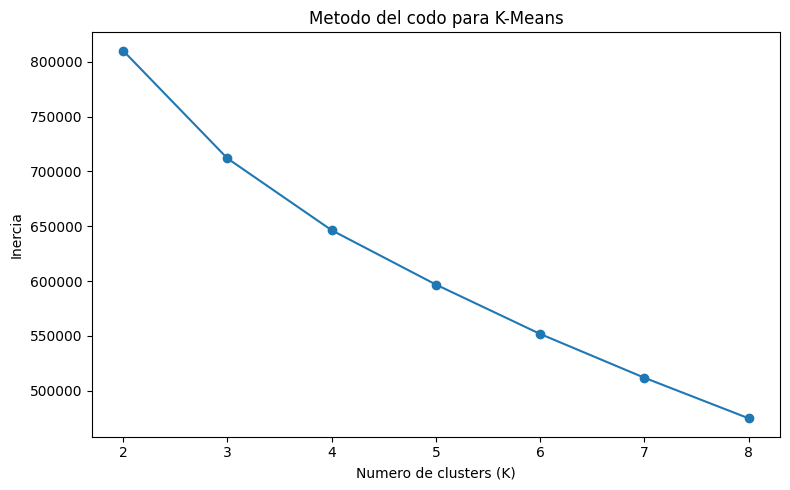

C:\Users\Usuario\Desktop\Machin\Spotify_ML\Spotify_ML_eva2\output\Graficos\metodo_codo.png


In [21]:
inertias = []
k_values = range(2, 9)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(list(k_values), inertias, marker="o")
ax.set_title("Metodo del codo para K-Means")
ax.set_xlabel("Numero de clusters (K)")
ax.set_ylabel("Inercia")
ax.set_xticks(list(k_values))
fig.tight_layout()
path = ROOT / "output/Graficos/metodo_codo.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
print(path)

### 3.1.1 Validacion cuantitativa con silhouette score

El metodo del codo es visual y puede ser ambiguo. Para respaldarlo con un numero, se calcula tambien el
*silhouette score* para cada K. Como el calculo exacto es costoso sobre ~90.000 filas (complejidad
cuadratica), se usa una muestra aleatoria fija de 10.000 canciones (`random_state=42`) para estimarlo,
mientras que el modelo K-Means en si se sigue ajustando con todos los datos.

In [22]:
from sklearn.metrics import silhouette_score

rng = np.random.RandomState(RANDOM_STATE)
sample_idx = rng.choice(X_cluster.shape[0], size=10000, replace=False)
X_sample = X_cluster[sample_idx]

sil_rows = []
for k in k_values:
    km_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = km_k.fit_predict(X_cluster)
    sil = silhouette_score(X_sample, km_k.predict(X_sample))
    sil_rows.append({"K": k, "inertia": km_k.inertia_, "silhouette": sil})

sil_df = pd.DataFrame(sil_rows)
sil_df.to_csv(ROOT / "output/Modelos/silhouette_scores.csv", index=False)
display(sil_df)

,K,inertia,silhouette
0,2,810206.030949,0.223126
1,3,711933.315705,0.251176
2,4,646372.173233,0.163453
3,5,596792.981783,0.166181
4,6,551720.553943,0.178127
5,7,511749.874359,0.187470
6,8,474739.059504,0.186874


### 3.1.2 Justificacion de K=5

El silhouette score **favorece levemente K=3** (0.251) por sobre K=5 (0.166); K=2 tambien queda por encima
de K=5 (0.223). Esto es esperable: el silhouette premia clusters pocos y muy separados, mientras que la
curva de inercia (metodo del codo) no muestra un quiebre unico y nitido, sino una disminucion gradual, tipica
de datos de audio reales donde los limites entre "tipos de cancion" son difusos y no categorias discretas.

Se decide **mantener K=5** en lugar del K=3 estadisticamente optimo por una razon de interpretabilidad para
el negocio: con K=3 los segmentos tienden a mezclar perfiles sonoros distintos (por ejemplo, musica acustica
de baja energia junto con musica clasica/ambiental), mientras que con K=5 los clusters quedan claramente
diferenciables y utiles (ver perfil de clusters y generos predominantes mas abajo): un segmento
"ambient/sleep/clasica", un segmento de alta energia/bailable, un segmento de metal/rock intenso, un segmento
acustico/romantico y un segmento de contenido explicito. Esta es una decision explicita de compromiso entre
pureza estadistica (K=3) y utilidad interpretativa para el caso de negocio (K=5), y se documenta como tal en
vez de presentar K=5 como el optimo matematico.

### 3.2 Aplicacion de K-Means

In [23]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_cluster)
df_cluster = full_df.copy()
df_cluster["cluster"] = cluster_labels
print("Clusters creados:", K)
display(df_cluster["cluster"].value_counts().sort_index().to_frame("cantidad"))

Clusters creados: 5


,cantidad
cluster,
0,7119
1,30797
2,24036
3,19782
4,8007


### 3.3 Perfil de clusters

In [24]:
cluster_profile = df_cluster.groupby("cluster")[cluster_features + ["popularity"]].mean().round(3)
display(cluster_profile)
cluster_profile.to_csv(ROOT / "output/Modelos/perfil_clusters.csv")

,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,popularity
cluster,,,,,,,,,,,,
0,222570.000,0.002,0.349,0.193,-20.880,0.053,0.830,0.783,0.173,0.177,102.771,28.625
1,214031.588,0.000,0.674,0.743,-6.414,0.083,0.208,0.054,0.209,0.704,122.015,33.824
2,271900.565,0.000,0.484,0.803,-6.348,0.079,0.071,0.279,0.251,0.306,135.087,32.747
3,213259.229,0.000,0.534,0.385,-10.577,0.056,0.681,0.062,0.187,0.409,113.666,33.141
4,203985.598,0.959,0.629,0.718,-6.834,0.237,0.248,0.052,0.262,0.467,120.996,36.355


### 3.4 Generos predominantes por cluster

In [25]:
genre_cluster = pd.crosstab(df_cluster["cluster"], full_df["track_genre"], normalize="index") * 100
for cluster in genre_cluster.index:
    print(f"\nCluster {cluster}  generos predominantes:")
    display(genre_cluster.loc[cluster].sort_values(ascending=False).head(5).round(2).to_frame("porcentaje"))


Cluster 0  generos predominantes:


,porcentaje
track_genre,
sleep,11.98
new-age,10.91
ambient,9.62
classical,8.78
iranian,6.45



Cluster 1  generos predominantes:


,porcentaje
track_genre,
forro,2.78
salsa,2.77
kids,2.63
afrobeat,2.30
disco,2.27



Cluster 2  generos predominantes:


,porcentaje
track_genre,
black-metal,3.44
grindcore,3.39
drum-and-bass,3.35
heavy-metal,3.25
happy,2.97



Cluster 3  generos predominantes:


,porcentaje
track_genre,
tango,4.48
honky-tonk,4.04
cantopop,3.71
romance,3.66
acoustic,3.18



Cluster 4  generos predominantes:


,porcentaje
track_genre,
comedy,11.38
emo,5.58
dancehall,3.70
hardcore,3.63
j-dance,3.62


### 3.4.1 Lectura de negocio de los segmentos

- **Cluster 0** (sleep, new-age, ambient, classical, iranian): baja energia, muy acustico/instrumental,
  popularidad promedio mas baja (28.6). Util para playlists de relajacion/concentracion.
- **Cluster 1** (forro, salsa, kids, afrobeat, disco): alta bailabilidad y energia, popularidad 33.8.
  Candidato natural a playlists de fiesta/baile.
- **Cluster 2** (black-metal, grindcore, drum-and-bass, heavy-metal): la mayor energia y menor valence
  (animo), popularidad 32.7. Segmento de nicho con audiencia muy definida.
- **Cluster 3** (tango, honky-tonk, cantopop, romance, acoustic): acustico, energia media-baja, popularidad
  33.1. Perfil "voz e instrumento" tradicional.
- **Cluster 4** (comedy, emo, dancehall, hardcore): concentra casi todo el contenido explicito (95.9% de
  explicit=True) y tiene la **mayor popularidad promedio del dataset (36.4)**. Es el unico segmento donde
  `explicit` es la variable mas distintiva, mas que las caracteristicas de audio.

Esta segmentacion es accionable para catalogacion y curaduria de playlists (agrupar por "tipo de experiencia
de escucha" en vez de solo por genero autodeclarado), que es justamente el tipo de patron que un modelo
supervisado de popularidad, por si solo, no revela.

### 3.5 Visualizacion con PCA

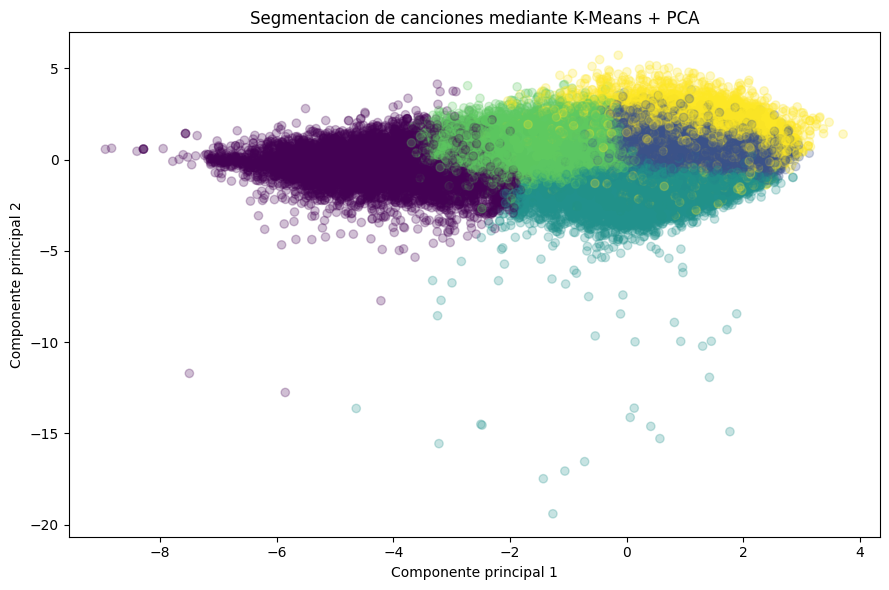

Varianza explicada PC1: 0.2657
Varianza explicada PC2: 0.1401


In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_cluster)
fig, ax = plt.subplots(figsize=(9,6))
ax.scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels, alpha=0.25)
ax.set_title("Segmentacion de canciones mediante K-Means + PCA")
ax.set_xlabel("Componente principal 1")
ax.set_ylabel("Componente principal 2")
fig.tight_layout()
path = ROOT / "output/Graficos/clusters_pca.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show(); plt.close(fig)
print("Varianza explicada PC1:", round(pca.explained_variance_ratio_[0],4))
print("Varianza explicada PC2:", round(pca.explained_variance_ratio_[1],4))

## 4. Cierre y conclusiones

**Modelado supervisado:** el Random Forest (MAE 14.53, RMSE 18.37, R2 0.192) supera a la Regresion Lineal
(MAE 17.05, RMSE 20.37, R2 0.007), confirmando que hay relaciones no lineales entre las variables y la
popularidad, pero ninguno de los dos modelos alcanza un poder predictivo alto: la mayor parte de la varianza
de `popularity` queda sin explicar por las variables disponibles en el dataset. Esto es consistente con el
EDA (correlaciones lineales debiles) y sugiere que la popularidad depende sobre todo de factores externos al
audio de la cancion (artista, marketing, distribucion en playlists).

**Aprendizaje no supervisado:** K-Means con K=5 identifica 5 segmentos sonoros claramente interpretables
(ver 3.4.1), que no dependen de la etiqueta `track_genre` original pero terminan correlacionando fuertemente
con agrupaciones de generos reconocibles. El segmento con mayor contenido explicito (cluster 4) es tambien el
de mayor popularidad promedio, un hallazgo que complementa al EDA del EP1 (que ya habia visto una diferencia
pequena pero significativa de popularidad segun `explicit`).

**Recomendacion para el negocio:** no usar el modelo de regresion como predictor unico de exito de una
cancion -su error es demasiado alto para decisiones de catalogo criticas-, pero si usar la segmentacion
no supervisada como herramienta de curaduria de contenido/playlists, y considerar incorporar variables
externas al dataset (senales de artista, redes sociales, playlists editoriales) para mejorar el poder
predictivo del modelo en una siguiente iteracion.

**Limitaciones:** dataset con muestreo artificialmente balanceado por genero (1.000 canciones por genero),
lo que no refleja la proporcion real del catalogo de Spotify; variables acusticas con bajo poder explicativo
lineal; K=5 elegido por interpretabilidad de negocio y no por ser el optimo segun silhouette score (ver
3.1.2).